<a href="https://colab.research.google.com/github/shub1504/ML_Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()   # a button will appear -> choose watermelon.csv from your PC

CSV_PATH = list(uploaded.keys())[0]
print("Loaded file:", CSV_PATH)

Saving watermelon.csv to watermelon.csv
Loaded file: watermelon.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_data(path):
    df = pd.read_csv(path)

    year_col = df.columns[9]
    yield_col = df.columns[11]

    data = df[[year_col, yield_col]].copy()
    data.columns = ["year", "yield"]

    data["year"] = pd.to_numeric(data["year"], errors="coerce")
    data["yield"] = pd.to_numeric(data["yield"], errors="coerce")
    data = data.dropna()

    data["year"] = data["year"].astype(int)

    return data


def train_linear_regression(years, yields):
    slope, intercept = np.polyfit(years, yields, 1)
    return slope, intercept


def predict(slope, intercept, year):
    return slope * year + intercept


def calculate_mse(years, yields, slope, intercept):
    predicted = slope * years + intercept
    return np.mean((yields - predicted) ** 2)

Slope     : 622.1061
Intercept : -1230095.8794

Mean Squared Error = 284834.5181

Predicted Yield
2027 -> 30913.11 kg/ha
2028 -> 31535.21 kg/ha
2029 -> 32157.32 kg/ha
2030 -> 32779.42 kg/ha

Graph saved to regression_plot.png


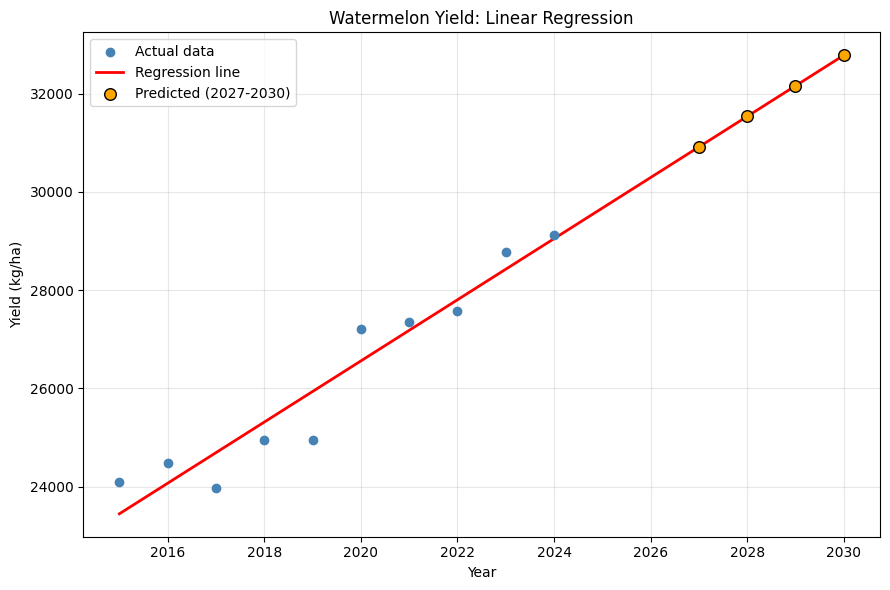

In [3]:
data = load_data(CSV_PATH)

if data.empty:
    print("No data found!")
else:
    years = data["year"].to_numpy()
    yields = data["yield"].to_numpy()

    slope, intercept = train_linear_regression(years, yields)
    mse = calculate_mse(years, yields, slope, intercept)

    print(f"Slope     : {slope:.4f}")
    print(f"Intercept : {intercept:.4f}")
    print(f"\nMean Squared Error = {mse:.4f}")

    predict_years = np.arange(2027, 2031)
    predict_yields = predict(slope, intercept, predict_years)

    print("\nPredicted Yield")
    for y, p in zip(predict_years, predict_yields):
        print(f"{y} -> {p:.2f} kg/ha")

    plt.figure(figsize=(9, 6))

    plt.scatter(years, yields, color="steelblue", label="Actual data", zorder=3)

    line_years = np.arange(years.min(), predict_years.max() + 1)
    line_yields = predict(slope, intercept, line_years)
    plt.plot(line_years, line_yields, color="red", linewidth=2, label="Regression line")

    plt.scatter(predict_years, predict_yields, color="orange", edgecolor="black",
                s=70, label="Predicted (2027-2030)", zorder=4)

    plt.title("Watermelon Yield: Linear Regression")
    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig("regression_plot.png", dpi=150)
    print("\nGraph saved to regression_plot.png")

    plt.show()